In [1]:
import phoebe
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['text.usetex'] = True
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
matplotlib.rcParams["font.size"] = 18
#rcParams["text.latex.preamble"] = r"\usepackage{cmbright}"
matplotlib.rcParams["savefig.dpi"] = 100
from scipy.optimize import curve_fit as cfit
from phoebe.atmospheres import models
from phoebe.atmospheres.passbands import InterpQuery


In [2]:
pb=phoebe.get_passband('SDSS:gprime')

First let's find the overlapping region in Teff and log g betwen the Tremblay and TMAP_DA grids

In [3]:
teffs=np.intersect1d(pb.ndp['tmap_DA'].axes[0], pb.ndp['tremblay'].axes[0])
loggs=np.intersect1d(pb.ndp['tmap_DA'].axes[1], pb.ndp['tremblay'].axes[1])

In [4]:
query_pts=np.array([np.ones(len(teffs)*len(loggs)),np.ones(len(teffs)*len(loggs))]).T
i=0
for x in range(0,len(teffs)):
    for y in range(0,len(loggs)):
        query_pts[i]=np.array([teffs[x],loggs[y]])
        i=i+1

query_table=InterpQuery(cols=['teffs','loggs'],pts=np.c_[query_pts])


In [5]:
Inorm_tmap=pb.interpolate_inorms(query=query_table, atm=models.TMAPDAModelAtmosphere, ld_func='linear', ld_coeffs=[0.0]).get_interpolated_values()
Inorm_tremblay=pb.interpolate_inorms(query=query_table, atm=models.TremblayModelAtmosphere, ld_func='linear', ld_coeffs=[0.0]).get_interpolated_values()

<>:2: SyntaxWarning: invalid escape sequence '\m'
<>:2: SyntaxWarning: invalid escape sequence '\m'
/var/folders/pg/hdw1chp161q7cjtzvbyw_zbc0000gq/T/ipykernel_4137/1522314913.py:2: SyntaxWarning: invalid escape sequence '\m'
  plt.colorbar(label="$T_\mathrm{eff}$ (K)")


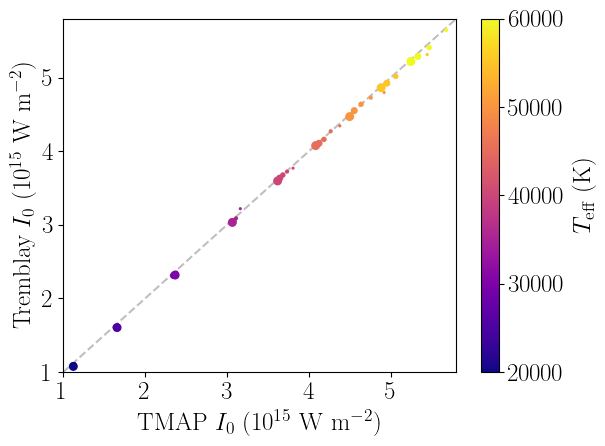

In [6]:
plt.scatter(Inorm_tmap/1e15,Inorm_tremblay/1e15,marker='.',c=query_pts.T[0],cmap='plasma',s=0.002*(query_pts.T[1])**5)
plt.colorbar(label="$T_\mathrm{eff}$ (K)")

straight=np.linspace(1.,5.8,10)
plt.plot(straight,straight,zorder=-10,ls='--',color='gray',alpha=0.5)
plt.xlim([1.,5.8])
plt.ylim([1.0,5.8])

plt.ylabel("Tremblay $I_0$ (10$^{15}$ W m$^{-2}$)")
plt.xlabel("TMAP $I_0$ (10$^{15}$ W m$^{-2}$)")
plt.tight_layout()
